# FS-5 · 업무 편중 점수(Workload/Overload Score) - 실험 노트북

담당: 이은주 (FS-5 ML/AI 모델링)

**목적**: 팀원별 업무 수·난이도·완료율 피처를 기반으로 과부하/저활동 팀원을 탐지.

**메인 방법**: MAD(Median Absolute Deviation) 기반 통계적 이상치 탐지
(Isolation Forest는 팀 규모(5~9명)에서 표본 부족으로 불안정함을 검증 과정에서 확인 → 아래 4장 참고)

**옵션 방법**: 룰베이스 점수를 pseudo-label 삼은 회귀 baseline (5장)

**위치**: 이 노트북은 `document_이은주/`에 있고, 실제 재사용 코드는
`App/backend_fastapi/ml_workload_score/app/services/workload_model.py`에 있습니다.
노트북은 그 함수들을 상대경로로 import해서 학습 과정과 검증 결과만 기록합니다
(FastAPI 서비스 코드와 실험 기록을 분리).


In [1]:
# 모듈 reload 편의를 위한 autoreload (venv/jupyter 공통)
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# 이 노트북은 document_이은주/ 에 위치, 실제 코드는 App/backend_fastapi/ 안의
# ml_workload_score 패키지에 있음. 리포 루트 기준 상대경로로 등록.
BACKEND_FASTAPI_PATH = (Path.cwd() / "../App/backend_fastapi").resolve()
if str(BACKEND_FASTAPI_PATH) not in sys.path:
    sys.path.insert(0, str(BACKEND_FASTAPI_PATH))
print("추가된 경로:", BACKEND_FASTAPI_PATH)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ml_workload_score.app.services.workload_model import (
    generate_synthetic_tasks,
    build_features,
    detect_overload_anomalies,
    detect_overload_anomalies_robust,
    detect_overload_anomalies_auto,
    optional_regression_baseline,
    rule_based_score,
    FEATURE_COLUMNS,
    CATEGORY_WEIGHT,
)

pd.set_option("display.width", 120)


추가된 경로: /home/claude/repo_sim/App/backend_fastapi


## 1. 합성 데이터 생성

실제 서비스 데이터(`tasks` 테이블)가 아직 충분히 쌓이지 않아, 파이프라인 검증용 합성 데이터를 사용합니다.
`assignee_5`는 의도적으로 과부하, `assignee_2`는 의도적으로 저활동 패턴으로 생성해서
모델이 실제로 탐지하는지 확인합니다.

In [2]:
tasks_df = generate_synthetic_tasks(n_members=7)
tasks_df.groupby("assignee_id").size().rename("task_count").to_frame()


,task_count
assignee_id,
assignee_1,6
assignee_2,3
assignee_3,9
assignee_4,10
assignee_5,15
assignee_6,7
assignee_7,7


## 2. 피처 엔지니어링

- `task_count_active_rel`: 팀 평균 대비 미완료 업무 수 비율
- `completion_rate`: 완료율
- `difficulty_avg_rel`: priority+category 가중치 평균의 팀 평균 대비 비율
- `overdue_ratio`: 마감 초과 업무 비율

난이도는 실제 DB에 필드가 없어 priority(옵션 A) + category 보정 가중치로 프록시 처리
(가중치 정의는 `workload_score.CATEGORY_WEIGHT` 참고).

In [3]:
features = build_features(tasks_df)
features[["assignee_id", "task_count_total", "task_count_active",
          "completion_rate", "difficulty_avg", "overdue_count"] ]


,assignee_id,task_count_total,task_count_active,completion_rate,difficulty_avg,overdue_count
0,assignee_1,6,5,0.166667,2.066667,3
1,assignee_2,3,1,0.666667,1.766667,0
2,assignee_3,9,7,0.222222,1.455556,2
3,assignee_4,10,9,0.100000,1.900000,1
4,assignee_5,15,11,0.266667,2.626667,7
5,assignee_6,7,2,0.714286,2.300000,2
6,assignee_7,7,4,0.428571,1.771429,1


## 3. 메인: 이상치 탐지 (MAD 기반, 팀 규모 자동 선택)

`detect_overload_anomalies_auto()`는 팀원 수가 15명 미만이면 MAD 기반,
15명 이상이면 Isolation Forest를 자동으로 선택합니다 (4장에서 이유 검증).

In [4]:
result = detect_overload_anomalies_auto(features)
print(f"사용된 방법: {result.attrs.get('method_used')}")
result[["assignee_id", "overload_score_0_100", "is_anomaly", "anomaly_type"]]


사용된 방법: MAD (소규모 팀)


,assignee_id,overload_score_0_100,is_anomaly,anomaly_type
4,assignee_5,100.000000,True,과부하 의심
5,assignee_6,73.706734,False,정상
1,assignee_2,66.173636,False,정상
2,assignee_3,53.153164,False,정상
0,assignee_1,49.232819,False,정상
3,assignee_4,37.693218,False,정상
6,assignee_7,28.068126,False,정상


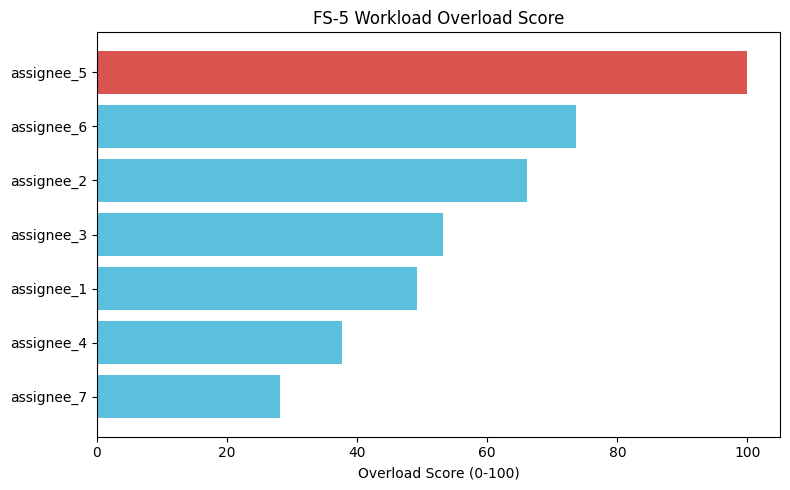

In [5]:
import os
os.makedirs("output", exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#d9534f" if a else "#5bc0de" for a in result["is_anomaly"]]
ax.barh(result["assignee_id"], result["overload_score_0_100"], color=colors)
ax.set_xlabel("Overload Score (0-100)")
ax.set_title("FS-5 Workload Overload Score")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("output/overload_score_result.png", dpi=150)
plt.show()


## 4. 검증: 왜 MAD 방식을 메인으로 선택했나 (Isolation Forest와 비교)

캡스톤 팀 규모(5~9명)를 가정한 5가지 엣지케이스로 두 방법을 비교합니다.
**소규모 표본에서 Isolation Forest가 실제로 불안정하게 작동함을 아래에서 확인했습니다.**

In [6]:
def make_tasks(assignments: dict, seed=42) -> pd.DataFrame:
    """assignments = {"assignee_1": n_tasks, ...} 형태로 간단히 tasks df 생성."""
    rng = np.random.default_rng(seed)
    categories = list(CATEGORY_WEIGHT.keys())
    priorities = ["낮음", "중간", "높음"]
    today = pd.Timestamp("2026-07-14")
    rows, task_id = [], 1
    for name, n in assignments.items():
        for _ in range(n):
            rows.append(dict(
                task_id=task_id, project_id=1, assignee_id=name,
                category=rng.choice(categories), priority=rng.choice(priorities),
                status=rng.choice(["할 일", "진행 중", "완료"], p=[0.3, 0.3, 0.4]),
                due_date=today + pd.Timedelta(days=int(rng.integers(-5, 15))),
            ))
            task_id += 1
    return pd.DataFrame(rows)


### 4-1. 극단적 편중 시나리오 (1명이 40개, 나머지 4명이 5개씩)

가장 중요한 검증 케이스. Isolation Forest는 이 케이스에서 **엉뚱한 사람을 이상치로 잡는 오류**를 보였습니다.

In [7]:
extreme = {"assignee_1": 40, **{f"assignee_{i}": 5 for i in range(2, 6)}}
extreme_tasks = make_tasks(extreme)
extreme_features = build_features(extreme_tasks)

print("--- Isolation Forest 결과 (문제 발생) ---")
if_result = detect_overload_anomalies(extreme_features)
display(if_result[["assignee_id", "task_count_total", "overload_score_0_100", "is_anomaly", "anomaly_type"]])

print("\n--- MAD 기반 결과 (정상 탐지) ---")
mad_result = detect_overload_anomalies_robust(extreme_features)
display(mad_result[["assignee_id", "task_count_total", "overload_score_0_100", "is_anomaly", "anomaly_type"]])


--- Isolation Forest 결과 (문제 발생) ---


,assignee_id,task_count_total,overload_score_0_100,is_anomaly,anomaly_type
4,assignee_5,5,100.000000,True,이상 패턴(방향 불명확)
0,assignee_1,40,80.803298,False,정상
3,assignee_4,5,35.415886,False,정상
2,assignee_3,5,23.983689,False,정상
1,assignee_2,5,0.000000,False,정상



--- MAD 기반 결과 (정상 탐지) ---


,assignee_id,task_count_total,overload_score_0_100,is_anomaly,anomaly_type
0,assignee_1,40,100.000000,True,과부하 의심
2,assignee_3,5,22.455443,False,정상
1,assignee_2,5,16.318411,False,정상
3,assignee_4,5,14.494281,False,정상
4,assignee_5,5,13.520083,False,정상


**해석**: `assignee_1`(40개, 명백한 과부하)을 Isolation Forest는 놓치고 엉뚱하게 `assignee_5`를 1위로 잡았습니다.
표본 5개로는 트리 기반 앙상블이 분할 기준을 안정적으로 잡지 못하기 때문입니다.
MAD 기반 방식은 `assignee_1`을 정확히 "과부하 의심"으로 잡아냈습니다 → **이 프로젝트는 MAD를 메인으로 채택.**

### 4-2. 균일한 팀 (전원 업무량 비슷 - 이상치가 없어야 정상)

In [8]:
uniform_tasks = make_tasks({f"assignee_{i}": 8 for i in range(1, 6)})
uniform_features = build_features(uniform_tasks)
uniform_result = detect_overload_anomalies_robust(uniform_features)
uniform_result[["assignee_id", "task_count_total", "overload_score_0_100", "is_anomaly", "anomaly_type"]]


,assignee_id,task_count_total,overload_score_0_100,is_anomaly,anomaly_type
3,assignee_4,8,100.000000,False,정상
1,assignee_2,8,70.463848,False,정상
4,assignee_5,8,64.384684,False,정상
0,assignee_1,8,57.917697,False,정상
2,assignee_3,8,0.000000,False,정상


**해석**: 오탐(false positive) 없이 전원 "정상"으로 나옴 — MAD=0(값이 몰려있을 때) 표준편차 폴백 처리 덕분에
초기 버전에서 발생했던 오탐 버그가 해결된 상태입니다.

### 4-3. 소규모 팀(2명) / 빈 프로젝트 / 팀원 1명 - 극단적 엣지케이스

In [9]:
small_team = make_tasks({"assignee_1": 3, "assignee_2": 15})
print("--- 2명 팀 ---")
display(detect_overload_anomalies_auto(build_features(small_team))
        [["assignee_id", "task_count_total", "overload_score_0_100", "is_anomaly"]])

single = make_tasks({"assignee_1": 10})
print("--- 팀원 1명 ---")
display(detect_overload_anomalies_auto(build_features(single))
        [["assignee_id", "task_count_total", "overload_score_0_100", "is_anomaly"]])

empty_df = pd.DataFrame(columns=["task_id","project_id","assignee_id","category","priority","status","due_date"])
print("--- 빈 프로젝트 ---")
print("업무 없음 - 이상치 탐지 대상 아님 (정상적으로 스킵되어야 함)")


--- 2명 팀 ---


,assignee_id,task_count_total,overload_score_0_100,is_anomaly
0,assignee_1,3,100.0,False
1,assignee_2,15,100.0,False


--- 팀원 1명 ---


,assignee_id,task_count_total,overload_score_0_100,is_anomaly
0,assignee_1,10,0.0,False


--- 빈 프로젝트 ---
업무 없음 - 이상치 탐지 대상 아님 (정상적으로 스킵되어야 함)


## 5. (옵션) Self-labeling 회귀 baseline

룰베이스 점수를 pseudo-label 삼아 선형회귀를 학습합니다.
**주의**: 진짜 라벨이 아니라 룰을 재현하는 모델이므로, R²가 높게 나오는 것이 "모델이 뛰어나다"는
의미가 아니라 "룰을 잘 재현했다"는 의미입니다. 실제 서비스 운영 후 팀장/심사자가 남긴
평가 라벨이 쌓이면 이 부분을 진짜 지도학습으로 교체할 예정입니다.

In [10]:
reg_model = optional_regression_baseline(features)



[옵션] Self-labeling 회귀 baseline
  R^2 (룰 재현도): 1.0000
  계수: {'task_count_active_rel': np.float64(0.4), 'completion_rate': np.float64(-0.3), 'difficulty_avg_rel': np.float64(0.2), 'overdue_ratio': np.float64(0.1)}


## 6. 다음 단계

- [ ] 실제 Supabase 데이터 연결 후 재검증 (`db.py` 참고)
- [ ] FastAPI `/ai/score/workload` 서비스 통합 (`main.py` 참고)
- [ ] FS-3(허영주) 지연 위험도 모델과 피처 공유 검토
- [ ] FS-4(고무서) 임베딩 파이프라인 지원
- [ ] 실제 라벨 축적 후 self-labeling → 지도학습 전환 검토
